In [34]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Linear Regression Analysis

In [44]:
df = pd.read_csv('data/fpl_features_last4_elo.csv')

In [54]:
df = df[df["target_points_next_gw"].notna()].copy()

Y = df["target_points_next_gw"]
X = df.drop(columns=["target_points_next_gw","name", "GW","kickoff_time", "opponent_team", "total_points", "GW", "season", "gw", "position", "team", "player_id", "META_position", "META_gw", "META_is_home"])
X.sort_index()
print(X.columns)
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

mae

Index(['assists', 'bonus', 'bps', 'clean_sheets', 'creativity', 'element',
       'fixture', 'goals_conceded', 'goals_scored', 'ict_index', 'influence',
       'minutes', 'own_goals', 'penalties_missed', 'penalties_saved',
       'red_cards', 'round', 'saves', 'selected', 'team_a_score',
       'team_h_score', 'threat', 'transfers_balance', 'transfers_in',
       'transfers_out', 'value', 'was_home', 'yellow_cards', 'xP',
       'expected_assists', 'expected_goal_involvements', 'expected_goals',
       'expected_goals_conceded', 'starts', 'FORM_total_points_mean_4',
       'FORM_total_points_sum_4', 'FORM_minutes_mean_4', 'FORM_minutes_sum_4',
       'FORM_goals_scored_sum_4', 'FORM_assists_sum_4', 'FORM_start_rate_4',
       'TEAM_ATT_goals_scored_mean_4', 'TEAM_DEF_goals_conceded_mean_4',
       'OPP_ATT_goals_scored_mean_4', 'OPP_DEF_goals_conceded_mean_4',
       'TEAM_elo', 'OPP_elo', 'RATE_goals_per_min', 'RATE_assists_per_min',
       'RATE_xG_per_min', 'RATE_xA_per_min', 'did_n

1.0835649576255697

MAE: 1.0835649576279716
                     Feature  Normalized_Coefficient
11                   minutes                0.649823
22         transfers_balance                0.463532
9                  ict_index                0.431202
23              transfers_in               -0.400708
24             transfers_out                0.352977
10                 influence               -0.320227
25                     value                0.255554
36       FORM_minutes_mean_4                0.218725
35   FORM_total_points_sum_4                0.173193
28                        xP                0.160743
51    did_not_play_last_game               -0.149204
40         FORM_start_rate_4               -0.145555
2                        bps                0.115473
18                  selected                0.113826
21                    threat               -0.099062
17                     saves                0.093020
15                 red_cards               -0.067747
4                 crea

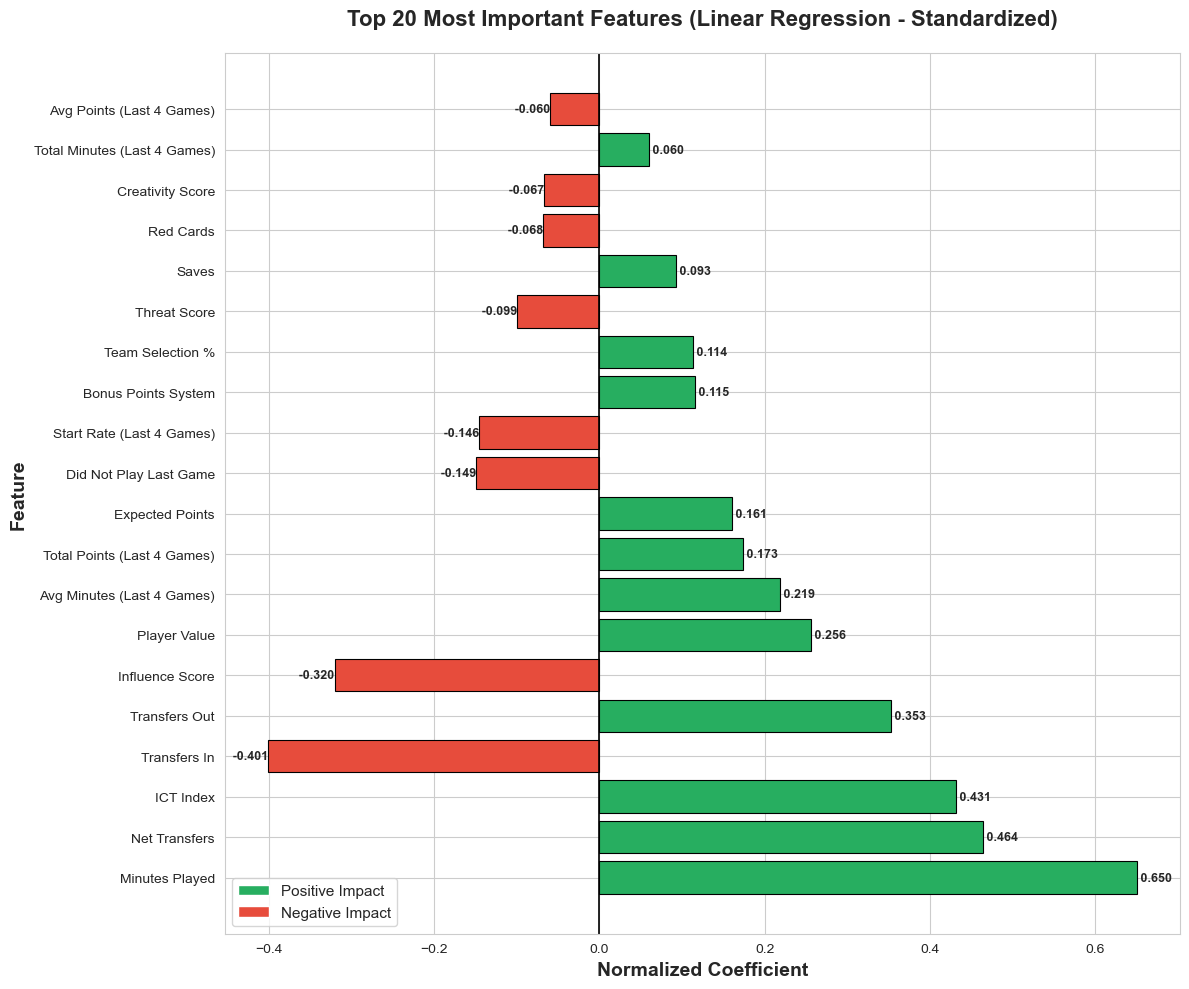

In [60]:
df = df[df["target_points_next_gw"].notna()].copy()
scaler = StandardScaler()

Y = df["target_points_next_gw"]
X = df.drop(columns=["target_points_next_gw","name", "GW","kickoff_time", "opponent_team", "total_points", "GW", "season", "gw", "position", "team", "player_id", "META_position", "META_gw", "META_is_home"])
X.sort_index()
X = X.fillna(0)
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

model_scaled = LinearRegression()
model_scaled.fit(X_train, y_train)

predictions_scaled = model_scaled.predict(X_test)  # Changed from model to model_scaled
mae_scaled = mean_absolute_error(y_test, predictions_scaled)  # Changed from predictions to predictions_scaled

print(f"MAE: {mae_scaled}")

# Now get normalized feature weights
feature_weights_normalized = pd.DataFrame({
    'Feature': X.columns,
    'Normalized_Coefficient': model_scaled.coef_
}).sort_values('Normalized_Coefficient', key=abs, ascending=False)

print(feature_weights_normalized.head(20))

import seaborn as sns

# Set style for cleaner look
sns.set_style("whitegrid")
plt.figure(figsize=(12, 10))

top_features = feature_weights_normalized.head(20).copy()  # Added .copy()
label_mapping = {
    'assists': 'Assists',
    'bonus': 'Bonus Points',
    'bps': 'Bonus Points System',
    'clean_sheets': 'Clean Sheets',
    'creativity': 'Creativity Score',
    'element': 'Player ID',
    'fixture': 'Fixture ID',
    'goals_conceded': 'Goals Conceded',
    'goals_scored': 'Goals Scored',
    'ict_index': 'ICT Index',
    'influence': 'Influence Score',
    'minutes': 'Minutes Played',
    'own_goals': 'Own Goals',
    'penalties_missed': 'Penalties Missed',
    'penalties_saved': 'Penalties Saved',
    'red_cards': 'Red Cards',
    'round': 'Gameweek Round',
    'saves': 'Saves',
    'selected': 'Team Selection %',
    'team_a_score': 'Away Team Score',
    'team_h_score': 'Home Team Score',
    'threat': 'Threat Score',
    'transfers_balance': 'Net Transfers',
    'transfers_in': 'Transfers In',
    'transfers_out': 'Transfers Out',
    'value': 'Player Value',
    'was_home': 'Home Game',
    'yellow_cards': 'Yellow Cards',
    'xP': 'Expected Points',
    'expected_assists': 'Expected Assists (xA)',
    'expected_goal_involvements': 'Expected Goal Involvements (xGI)',
    'expected_goals': 'Expected Goals (xG)',
    'expected_goals_conceded': 'Expected Goals Conceded (xGC)',
    'starts': 'Games Started',
    'FORM_total_points_mean_4': 'Avg Points (Last 4 Games)',
    'FORM_total_points_sum_4': 'Total Points (Last 4 Games)',
    'FORM_minutes_mean_4': 'Avg Minutes (Last 4 Games)',
    'FORM_minutes_sum_4': 'Total Minutes (Last 4 Games)',
    'FORM_goals_scored_sum_4': 'Goals (Last 4 Games)',
    'FORM_assists_sum_4': 'Assists (Last 4 Games)',
    'FORM_start_rate_4': 'Start Rate (Last 4 Games)',
    'TEAM_ATT_goals_scored_mean_4': 'Team Attack: Avg Goals',
    'TEAM_DEF_goals_conceded_mean_4': 'Team Defense: Avg Goals Conceded',
    'OPP_ATT_goals_scored_mean_4': 'Opponent Attack: Avg Goals',
    'OPP_DEF_goals_conceded_mean_4': 'Opponent Defense: Avg Goals Conceded',
    'TEAM_elo': 'Team Elo Rating',
    'OPP_elo': 'Opponent Elo Rating',
    'RATE_goals_per_min': 'Goals per Minute',
    'RATE_assists_per_min': 'Assists per Minute',
    'RATE_xG_per_min': 'xG per Minute',
    'RATE_xA_per_min': 'xA per Minute',
    'did_not_play_last_game': 'Did Not Play Last Game',
}
top_features['Feature_Label'] = top_features['Feature'].map(label_mapping).fillna(top_features['Feature'])

# Color bars based on positive/negative
colors = ['#27ae60' if x > 0 else '#e74c3c' for x in top_features['Normalized_Coefficient']]

# Create bars with edge color for definition - CHANGED TO Feature_Label
bars = plt.barh(top_features['Feature_Label'], top_features['Normalized_Coefficient'], 
                color=colors, edgecolor='black', linewidth=0.8)

# Add value labels on bars
for i, (idx, row) in enumerate(top_features.iterrows()):
    value = row['Normalized_Coefficient']
    plt.text(value, i, f' {value:.3f}', 
             va='center', ha='left' if value > 0 else 'right',
             fontweight='bold', fontsize=9)

# Styling
plt.xlabel('Normalized Coefficient', fontsize=14, fontweight='bold')
plt.ylabel('Feature', fontsize=14, fontweight='bold')
plt.title('Top 20 Most Important Features (Linear Regression - Standardized)', 
          fontsize=16, fontweight='bold', pad=20)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.2)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#27ae60', label='Positive Impact'),
                   Patch(facecolor='#e74c3c', label='Negative Impact')]
plt.legend(handles=legend_elements, loc='lower left', fontsize=11)

plt.tight_layout()
plt.savefig('feature_weights_final.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
# If you need to get position from the original df
test_indices = X_test.index
test_positions = df.loc[test_indices, 'position']  # or 'META_position'

# Calculate MAE by position
for position in ['FWD', 'MID', 'DEF', 'GK']:
    mask = test_positions == position
    if mask.sum() > 0:
        actual = y_test[mask]
        pred = predictions[mask]
        mae_pos = mean_absolute_error(actual, pred)
        print(f"{position}: MAE = {mae_pos:.3f} (n={mask.sum()})")

FWD: MAE = 1.199 (n=2604)
MID: MAE = 1.035 (n=8680)
DEF: MAE = 1.125 (n=6945)
GK: MAE = 0.726 (n=2338)


In [48]:
lin_reg_results = {
    "Overall MAE": mae,
    "FWD MAE": 1.199,
    "MID MAE": 1.035,
    "DEF MAE": 1.125,
    "GK MAE": 0.726}

lin_reg_df = pd.DataFrame(list(lin_reg_results.items()), 
                          columns=['Position', 'Linear Regression MAE'])


In [49]:
lin_reg_df

,Position,Linear Regression MAE
0,Overall MAE,1.083565
1,FWD MAE,1.199000
2,MID MAE,1.035000
3,DEF MAE,1.125000
4,GK MAE,0.726000
